In [2]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder

# Variables
file_name= 'mba.csv'
random_state = 42

np.random.seed(random_state)
df = pd.read_csv(file_name)
df.head()

,Item(s),Item 1,Item 2,Item 3,Item 4,Item 5,Item 6,Item 7,Item 8,Item 9,...,Item 23,Item 24,Item 25,Item 26,Item 27,Item 28,Item 29,Item 30,Item 31,Item 32
0,4,citrus fruit,semi-finished bread,margarine,ready soups,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,tropical fruit,yogurt,coffee,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,whole milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,pip fruit,yogurt,cream cheese,meat spreads,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,other vegetables,whole milk,condensed milk,long life bakery product,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### generate a dataframe basket of boolean values with one row per transaction and one column per distinct item of the database; the dataframe values must be True if a distinct item is contained in the transaction

In [8]:
# Open the file
file = open(file_name, mode = 'r')

# The transactions are separated by a ','
# We must also strip the '\n' at the end of the transaction
transactions = [line.strip('\n').split(',') for line in file.readlines()]

# The first line contains field names that are not relevant, so let's skip it
transactions = transactions[1:]

# The first item in every transaction is a number of the items in the transaction
# we want to use it to slice the list, removing all the empty strings and the 
# number itself
for i in range(len(transactions)):

        # The end index is the number of items in the transaction
        # plus one, because we have the number itself in the slot 0
        end_index = int(transactions[i][0]) + 1
        transactions[i] = transactions[i][1:end_index]

# We now have a list of transactions with only the items in them, we can now
# use TransactionEncoder to obtain an encoded version in boolean form
encoder = TransactionEncoder()
encoded_transactions = encoder.fit_transform(transactions)

# We can now put the encoded transactions in a dataframe
basket = pd.DataFrame(encoded_transactions)
basket.head()

,0,1,2,3,4,5,6,7,8,9,...,159,160,161,162,163,164,165,166,167,168
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### ignore the transactions containing a single item

In [9]:
n_items = 1
single_item_transactions = []
# Iterate on all transactions
for index, transaction in basket.iterrows():
    # If there is just one "True" value
    count = 0
    for item in transaction:
        if item == True :
            count = count + 1
    if count <= n_items:
        # Save the index of the transaction
        single_item_transactions.append(index)
# We can now drop those transactions from the dataframe
basket.drop(index = single_item_transactions, axis = 0, inplace = True)
basket.shape

(7676, 169)

### the column names of the output dataframe are the distinct items
### show the first five rows of the output dataframe

In [12]:
basket.columns=encoder.columns_
basket.head()


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
5,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False


### show the number of transactions and of distinct items

In [14]:
print(f"number of trasaction: {basket.shape[0]} number of items: {basket.shape[1]}")

number of trasaction: 7676 number of items: 169


### find a value of min_support such that the apriori algorithm generates at least 8 frequent itemsets with at least 2 items

In [21]:
# Requirements
min_itemsets = 8
min_item_in_itemset = 2
# "Reasonable" range
support_range = np.arange(0.1, 0.01, -0.01)

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
min_support = 0
for s_value in support_range:
    print(f"Trying support value {s_value:.2f}")
    frequent_itemsets = apriori(basket, min_support = s_value, use_colnames = True)
    # Calculate the number of itemsets that contain at least `min_item_in_itemset` items
    # frequent_itemsets must contains al least min_itemsets itemsset , and every item set must contains al least min_item_in_itemset item
    itemsets_above_threshold = sum([len(itemset) >= min_item_in_itemset for itemset in frequent_itemsets.itemsets])
    if itemsets_above_threshold >= min_itemsets:
        min_support = s_value
        break
if min_support == 0:
    print("No itemset found! Try again with a bigger range!")
else:
    print(f"I've selected min_support = {min_support:.2f}, which produced , {len(frequent_itemsets)} itemsets, {itemsets_above_threshold} of which had more than {min_item_in_itemset} items")

Trying support value 0.10
Trying support value 0.09
Trying support value 0.08
Trying support value 0.07
Trying support value 0.06
Trying support value 0.05
I've selected min_support = 0.05, which produced , 42 itemsets, 9 of which had more than 2 items


### find the minimum metric threshold such that at least 10 association rules are extracted from the frequent itemsets found

In [22]:
#Requirment
metric_threshold_range = np.arange(20, 0.01, -0.01)
min_association_rule = 10
min_metric_threshold = 0
association_rule_found = 0
current_metric = "confidence"

for metric_value in metric_threshold_range:

    rules = association_rules(frequent_itemsets, metric=current_metric, min_threshold=metric_value)
    if rules.shape[0] >= min_association_rule:
        association_rule_found = rules.shape[0]
        min_metric_threshold = metric_value
        break

if association_rule_found == 0:
    print("No association rule! Try again with a bigger range!")
else:
    print(f"I've selected metric {current_metric}  with metric_value = {metric_value:.4f}, which produced , {association_rule_found} association_rules")

I've selected metric confidence  with metric_value = 0.2500, which produced , 10 association_rules


### print the first 10 rules found, sorted by descending confidence and support

In [27]:
rules=rules.sort_values(by=['confidence', 'support'], ascending=False).reset_index(drop=True)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(root vegetables),(whole milk),0.136399,0.311621,0.062663,0.459408,1.474254,1.0,0.020158,1.273380,0.372499,0.162610,0.214689,0.330247
1,(root vegetables),(other vegetables),0.136399,0.239838,0.060709,0.445081,1.855754,1.0,0.027995,1.369861,0.533968,0.192403,0.269999,0.349102
2,(yogurt),(whole milk),0.173528,0.311621,0.071782,0.413664,1.327459,1.0,0.017707,1.174035,0.298475,0.173653,0.148237,0.322007
3,(tropical fruit),(whole milk),0.131449,0.311621,0.054195,0.412289,1.323049,1.0,0.013233,1.171290,0.281123,0.139363,0.146240,0.293101
4,(other vegetables),(whole milk),0.239838,0.311621,0.095883,0.399783,1.282915,1.0,0.021145,1.146884,0.290103,0.210466,0.128072,0.353738
5,(rolls/buns),(whole milk),0.221470,0.311621,0.072564,0.327647,1.051429,1.0,0.003549,1.023836,0.062828,0.157567,0.023281,0.280253
6,(yogurt),(other vegetables),0.173528,0.239838,0.055628,0.320571,1.336610,1.0,0.014009,1.118823,0.304715,0.155499,0.106204,0.276255
7,(whole milk),(other vegetables),0.311621,0.239838,0.095883,0.307692,1.282915,1.0,0.021145,1.098011,0.320354,0.210466,0.089262,0.353738
8,(other vegetables),(root vegetables),0.239838,0.136399,0.060709,0.253123,1.855754,1.0,0.027995,1.156283,0.606628,0.192403,0.135160,0.349102
9,(soda),(whole milk),0.203101,0.311621,0.051329,0.252726,0.811006,1.0,-0.011962,0.921187,-0.226263,0.110768,-0.085555,0.208721


 ### plot confidence and support for all the sorted rules found

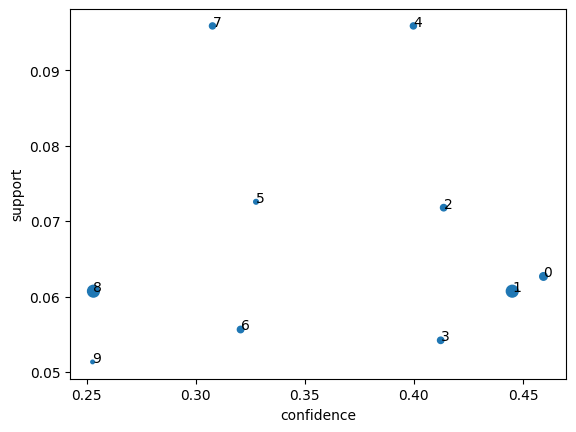

In [56]:
fig=rules.plot.scatter(x='confidence',y='support',s=[10**n for n in rules.lift])

for i in range(len(rules)):
    fig.annotate(text = i, xy = (rules['confidence'][i], rules['support'][i]))

<Axes: title={'center': 'Association rules'}>

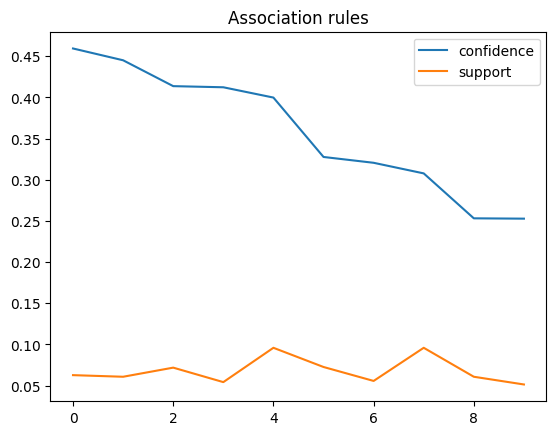

In [57]:
rules[['confidence','support']].plot(title="Association rules")